In [8]:
import pandas as pd
import numpy as np
from pprint import pprint

In [3]:
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
df.head(5)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [11]:
pprint(df.isnull().sum())
print(f"The number of duplicate rows is: {df.duplicated().sum()}")

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [26]:
print(f"The columns in the DataFrame are: {df.columns.tolist()}\nThe number of rows and columns in the DataFrame are: {df.shape}")

The columns in the DataFrame are: ['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']
The number of rows and columns in the DataFrame are: (1470, 35)


In [22]:
print(f"Different entries for 'BusinessTravel': {df['BusinessTravel'].unique()}\n")
print(f"Different entries for 'Department': {df['Department'].unique()}\n")
print(f"Different entries for 'EducationField': {df['EducationField'].unique()}\n")
print(f"Different entries for job role: {df['JobRole'].unique()}\n")
print(f"Different entries for 'MaritalStatus': {df['MaritalStatus'].unique()}\n")

Different entries for 'BusinessTravel': ['Travel_Rarely' 'Travel_Frequently' 'Non-Travel']

Different entries for 'Department': ['Sales' 'Research & Development' 'Human Resources']

Different entries for 'EducationField': ['Life Sciences' 'Other' 'Medical' 'Marketing' 'Technical Degree'
 'Human Resources']

Different entries for job role: ['Sales Executive' 'Research Scientist' 'Laboratory Technician'
 'Manufacturing Director' 'Healthcare Representative' 'Manager'
 'Sales Representative' 'Research Director' 'Human Resources']

Different entries for 'MaritalStatus': ['Single' 'Married' 'Divorced']



In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

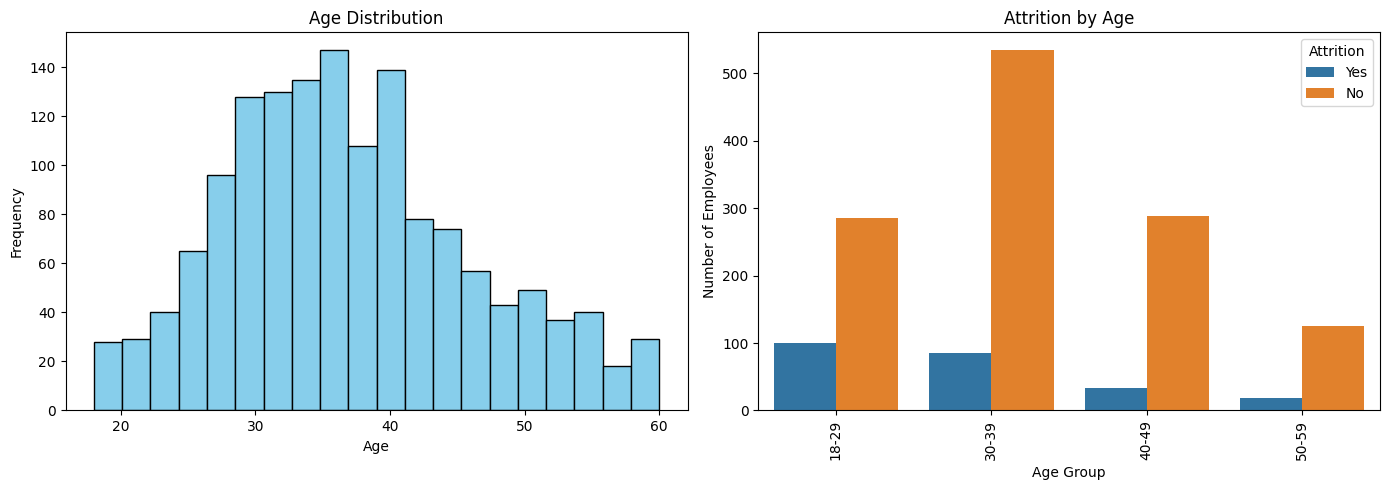

In [50]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))


ax[0].hist(df["Age"], bins=20, color="skyblue", edgecolor="black")
ax[0].set_title("Age Distribution")
ax[0].set_xlabel("Age")
ax[0].set_ylabel("Frequency")


df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[18, 30, 40, 50, 60],
    labels=["18-29", "30-39", "40-49", "50-59"],
    include_lowest=True
)

sns.countplot(
    data=df,
    x="AgeGroup",
    hue="Attrition",
    ax=ax[1],
)

ax[1].set_title("Attrition by Age")
ax[1].set_xlabel("Age Group")
ax[1].set_ylabel("Number of Employees")
ax[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

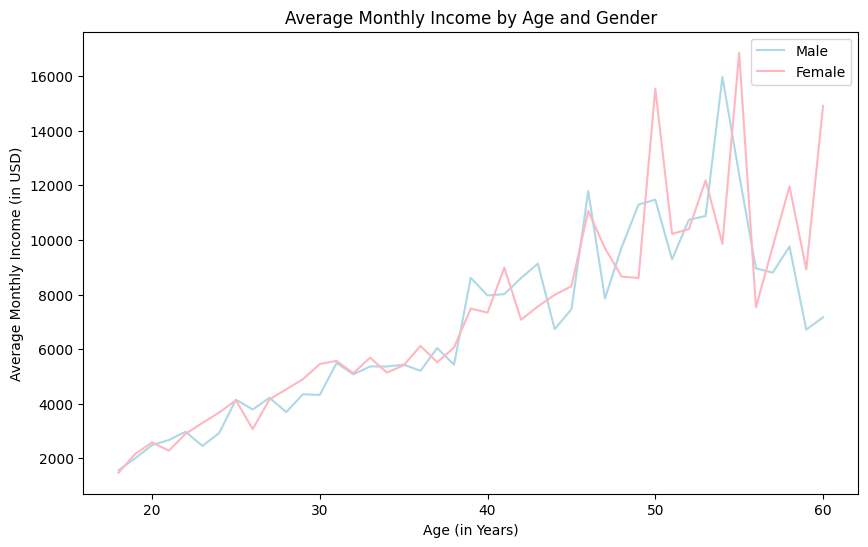

In [38]:
male = df[df["Gender"] == "Male"]
female = df[df["Gender"] == "Female"]
plt.figure(figsize=(10, 6))
plt.plot(
    male.groupby("Age")["MonthlyIncome"].mean(),
    label="Male", color='lightblue'
)
plt.plot(
    female.groupby("Age")["MonthlyIncome"].mean(),
    label="Female", color='lightpink'
)
plt.xlabel("Age (in Years)")
plt.ylabel("Average Monthly Income (in USD)")
plt.title("Average Monthly Income by Age and Gender")
plt.legend()

plt.show()